In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_data = datasets.MNIST(
    "./data", train=True, download=True, transform=transform
)

test_data = datasets.MNIST(
    "./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

print("Device:", device)
print("Train:", len(train_data))
print("Test:", len(test_data))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.81MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.10MB/s]

Device: cpu
Train: 60000
Test: 10000


In [3]:
def train_vae(latent_dim, epochs=20):

    model = VAE(latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):

        total_loss = 0

        for images, _ in train_loader:

            images = images.view(images.size(0), -1).to(device)

            reconstruction, mu, logvar = model(images)

            recon_loss = F.binary_cross_entropy(
                reconstruction,
                images,
                reduction="sum"
            )

            kl_loss = -0.5 * torch.sum(
                1 + logvar - mu.pow(2) - logvar.exp()
            )

            loss = recon_loss + kl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {total_loss / len(train_data):.2f}"
        )

    return model


# Train VAE with latent dimension 2
model = train_vae(latent_dim=2, epochs=20)

Epoch 1/20 | Loss: 207.29
Epoch 2/20 | Loss: 176.85
Epoch 3/20 | Loss: 169.57
Epoch 4/20 | Loss: 166.43
Epoch 5/20 | Loss: 164.51
Epoch 6/20 | Loss: 162.98
Epoch 7/20 | Loss: 161.78
Epoch 8/20 | Loss: 160.77
Epoch 9/20 | Loss: 159.90
Epoch 10/20 | Loss: 159.12
Epoch 11/20 | Loss: 158.50
Epoch 12/20 | Loss: 157.97
Epoch 13/20 | Loss: 157.43
Epoch 14/20 | Loss: 156.99
Epoch 15/20 | Loss: 156.56
Epoch 16/20 | Loss: 156.19
Epoch 17/20 | Loss: 155.86
Epoch 18/20 | Loss: 155.56
Epoch 19/20 | Loss: 155.28
Epoch 20/20 | Loss: 155.04


In [4]:
# Part A: Compression

sample_image, _ = test_data[0]

x = sample_image.view(1, -1).to(device)

mu, logvar = model.encode(x)

print("Original image size:", x.shape[1])
print("Latent representation size:", mu.shape[1])

compression_ratio = 784 / 2

print("Compression Ratio:", compression_ratio, ": 1")

Original image size: 784
Latent representation size: 2
Compression Ratio: 392.0 : 1


In [5]:
# Part B: Reconstruction

images, labels = next(iter(DataLoader(
    test_data, batch_size=10, shuffle=False
)))

images_flat = images.view(10, -1).to(device)

with torch.no_grad():
    mu, logvar = model.encode(images_flat)
    reconstructed = model.decode(mu)

mse = F.mse_loss(reconstructed, images_flat)

print("Reconstruction MSE:", mse.item())

Reconstruction MSE: 0.041062504053115845


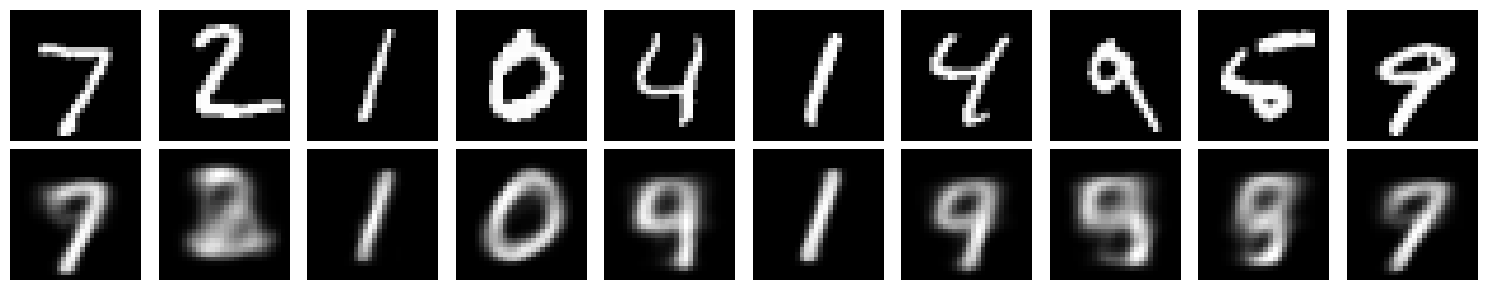

In [6]:
# Display original and reconstructed images

fig, axes = plt.subplots(2, 10, figsize=(15, 3))

for i in range(10):

    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(
        reconstructed[i].cpu().view(28, 28),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstructed")

plt.tight_layout()
plt.show()

In [7]:
# Part C: Add Gaussian noise

noise = torch.randn_like(images_flat) * 0.3

noisy_images = torch.clamp(
    images_flat + noise,
    0,
    1
)

with torch.no_grad():
    mu, logvar = model.encode(noisy_images)
    denoised_images = model.decode(mu)

print("Gaussian noise added successfully.")

Gaussian noise added successfully.


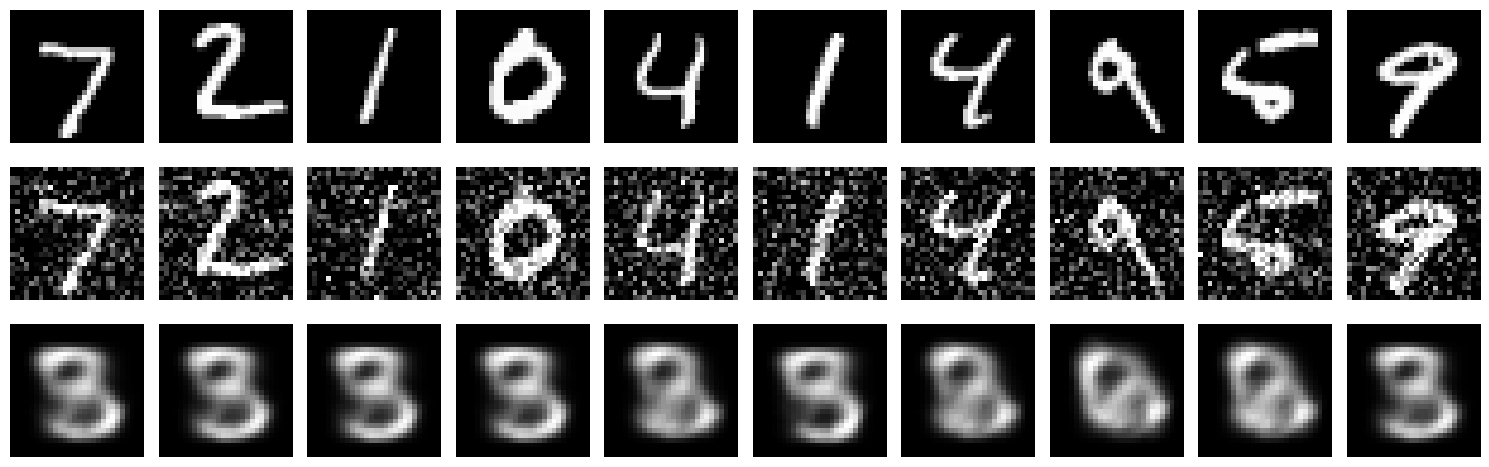

In [8]:
# Display denoising results

fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for i in range(10):

    # Original
    axes[0, i].imshow(
        images[i].squeeze(),
        cmap="gray"
    )
    axes[0, i].axis("off")

    # Noisy
    axes[1, i].imshow(
        noisy_images[i].cpu().view(28, 28),
        cmap="gray"
    )
    axes[1, i].axis("off")

    # Denoised
    axes[2, i].imshow(
        denoised_images[i].cpu().view(28, 28),
        cmap="gray"
    )
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Noisy")
axes[2, 0].set_ylabel("Denoised")

plt.tight_layout()
plt.show()

In [9]:
# Part D: VAE with latent dimension 16

model_16 = train_vae(latent_dim=16, epochs=20)

Epoch 1/20 | Loss: 191.58
Epoch 2/20 | Loss: 137.26
Epoch 3/20 | Loss: 125.95
Epoch 4/20 | Loss: 121.29
Epoch 5/20 | Loss: 118.68
Epoch 6/20 | Loss: 116.88
Epoch 7/20 | Loss: 115.49
Epoch 8/20 | Loss: 114.50
Epoch 9/20 | Loss: 113.68
Epoch 10/20 | Loss: 112.99
Epoch 11/20 | Loss: 112.40
Epoch 12/20 | Loss: 111.94
Epoch 13/20 | Loss: 111.56
Epoch 14/20 | Loss: 111.22
Epoch 15/20 | Loss: 110.91
Epoch 16/20 | Loss: 110.62
Epoch 17/20 | Loss: 110.40
Epoch 18/20 | Loss: 110.15
Epoch 19/20 | Loss: 109.87
Epoch 20/20 | Loss: 109.70


In [10]:
# Part D: VAE with latent dimension 32

model_32 = train_vae(latent_dim=32, epochs=20)

Epoch 1/20 | Loss: 192.07
Epoch 2/20 | Loss: 141.09
Epoch 3/20 | Loss: 128.93
Epoch 4/20 | Loss: 122.64
Epoch 5/20 | Loss: 118.65
Epoch 6/20 | Loss: 116.26
Epoch 7/20 | Loss: 114.62
Epoch 8/20 | Loss: 113.39
Epoch 9/20 | Loss: 112.49
Epoch 10/20 | Loss: 111.74
Epoch 11/20 | Loss: 111.21
Epoch 12/20 | Loss: 110.77
Epoch 13/20 | Loss: 110.37
Epoch 14/20 | Loss: 110.02
Epoch 15/20 | Loss: 109.76
Epoch 16/20 | Loss: 109.48
Epoch 17/20 | Loss: 109.29
Epoch 18/20 | Loss: 109.09
Epoch 19/20 | Loss: 108.94
Epoch 20/20 | Loss: 108.77


In [11]:
# Compare latent dimensions

models = {
    2: model,
    16: model_16,
    32: model_32
}

results = []

for latent_dim, vae in models.items():

    vae.eval()

    with torch.no_grad():
        mu, logvar = vae.encode(images_flat)
        reconstructed = vae.decode(mu)

    mse = F.mse_loss(reconstructed, images_flat).item()
    compression_ratio = 784 / latent_dim

    results.append([
        latent_dim,
        compression_ratio,
        mse
    ])

print("Comparison completed.")

Comparison completed.


In [14]:
# Final Results Table

results_df["Reconstruction Quality"] = [
    "Blurry - more information lost",
    "Improved reconstruction",
    "Better detail preservation"
]

results_df["Denoising Observations"] = [
    "Noise reduced, but output is blurry",
    "Better preservation of digit structure",
    "Better preservation of details"
]

results_df

,Latent Dimension,Compression Ratio,Reconstruction MSE,Reconstruction Quality,Denoising Observations
0,2,392.0,0.041063,Blurry - more information lost,"Noise reduced, but output is blurry"
1,16,49.0,0.011911,Improved reconstruction,Better preservation of digit structure
2,32,24.5,0.009794,Better detail preservation,Better preservation of details


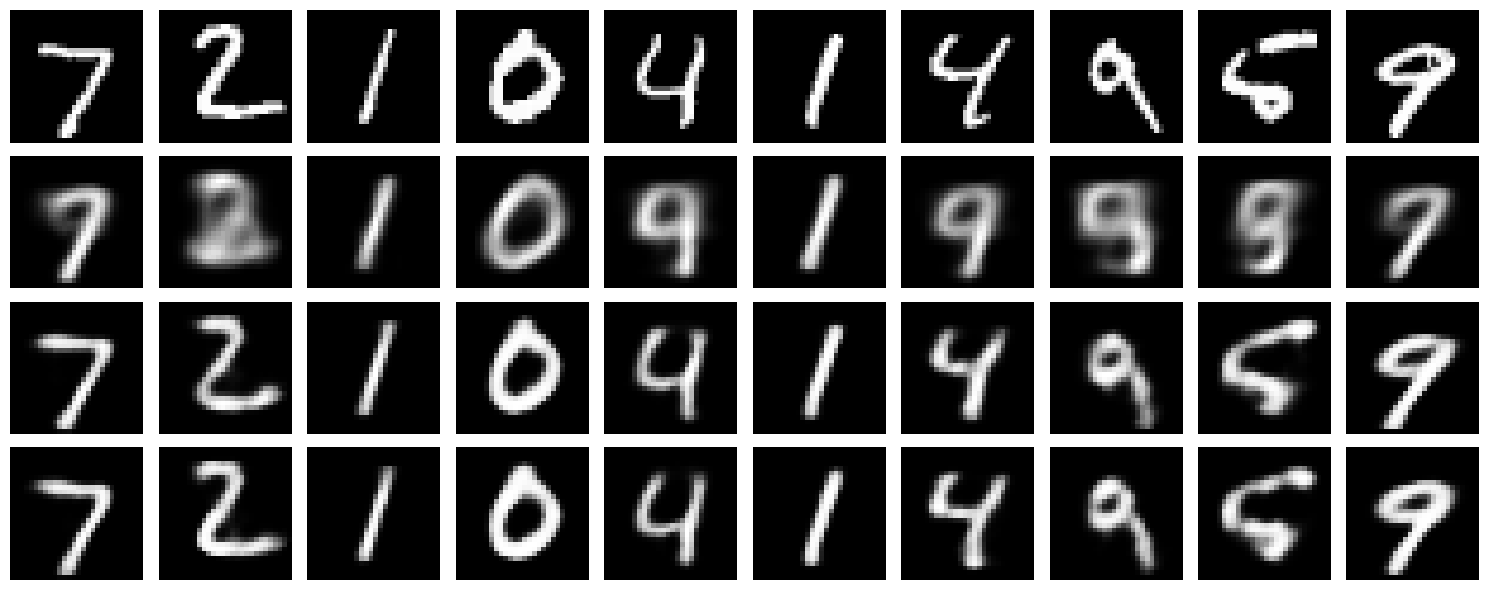

In [13]:
# Visual comparison of different latent dimensions

fig, axes = plt.subplots(4, 10, figsize=(15, 6))

models_list = [
    ("Original", None),
    ("Latent 2", model),
    ("Latent 16", model_16),
    ("Latent 32", model_32)
]

for row, (title, vae) in enumerate(models_list):

    for i in range(10):

        if vae is None:
            image = images[i]
        else:
            vae.eval()
            with torch.no_grad():
                mu, _ = vae.encode(images_flat)
                image = vae.decode(mu)[i].cpu().view(28, 28)

        axes[row, i].imshow(
            image.squeeze(),
            cmap="gray"
        )
        axes[row, i].axis("off")

    axes[row, 0].set_ylabel(title)

plt.tight_layout()
plt.show()

### Observations

1. The original MNIST images contain 784 pixel values, while the VAE compresses them into a smaller latent representation.

2. With latent dimension 2, the compression ratio is 392:1. The reconstructed images are blurrier because more information is compressed.

3. With latent dimension 16, the compression ratio is 49:1 and the reconstruction quality improves compared with latent dimension 2.

4. With latent dimension 32, the compression ratio is 24.5:1 and the reconstructed images preserve more visual details.

5. Gaussian noise was added to 10 test images. The VAE was able to reduce some of the noise, although the denoised images were slightly blurred.

### Conclusion

The experiment shows that a Variational Autoencoder can be used for both image compression and basic denoising. A smaller latent dimension provides higher compression but loses more information, while larger latent dimensions improve reconstruction quality at the cost of lower compression.